# 02: Climate Data Exploration

**Source**: [Government of Canada — Adjusted and Homogenized Canadian Climate Data (AHCCD)](https://open.canada.ca/data/en/dataset/d6813de6-b20a-46cc-8990-01862ae15c5f)

**Direct Link**: [All AHCCD Files are Directly available here](https://crd-data-donnees-rdc.ec.gc.ca/CDAS/products/EC_data/AHCCD_daily/)

## Scope
- **Time window**: 1924–2017 (full overlap of all climate and disease datasets)
- **Geography**: Province-level aggregation across all 13 Canadian provinces/territories
- **Climate features**: daily max/mean/min temperature; daily rain, snow, total precipitation → aggregated to monthly

## Data Sources
| Dataset | Files | Coverage |
|---|---|---|
| Homogenized daily max temp | `Homog_daily_max_temp_v2023_Gen3/dx*.txt` | ~1840–2023 |
| Homogenized daily mean temp | `Homog_daily_mean_temp_v2023_Gen3/dm*.txt` | ~1840–2023 |
| Homogenized daily min temp | `Homog_daily_min_temp_v2023_Gen3/dn*.txt` | ~1840–2023 |
| Adjusted daily rainfall | `Adj_Daily_Rain_v2017/dr*.txt` | ~1840–2017 |
| Adjusted daily snowfall | `Adj_Daily_Snow_v2017/ds*.txt` | ~1840–2017 |
| Adjusted daily total precip | `Adj_Daily_Total_v2017/dt*.txt` | ~1840–2017 |
| Temperature station metadata | `Temperature_Stations_Gen3_2023.xlsx` | — |
| Precipitation station metadata | `Adj_Precipitation_Stations.xls` | — |


In [ ]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT    = Path('/Users/deansimmer/git/AAI-590-capstone-canadian-health')  # adjust as needed
DATA_DIR     = REPO_ROOT / 'data'
CLIMATE_ROOT = DATA_DIR / 'raw' / 'climate'

TEMP_MAX_DIR   = CLIMATE_ROOT / 'Homog_daily_max_temp_v2023_Gen3'
TEMP_MEAN_DIR  = CLIMATE_ROOT / 'Homog_daily_mean_temp_v2023_Gen3'
TEMP_MIN_DIR   = CLIMATE_ROOT / 'Homog_daily_min_temp_v2023_Gen3'
RAIN_DIR       = CLIMATE_ROOT / 'Adj_Daily_Rain_v2017'
SNOW_DIR       = CLIMATE_ROOT / 'Adj_Daily_Snow_v2017'
TOTAL_DIR      = CLIMATE_ROOT / 'Adj_Daily_Total_v2017'

TEMP_META_FILE   = CLIMATE_ROOT / 'Temperature_Stations_Gen3_2023.xlsx'
PRECIP_META_FILE = CLIMATE_ROOT / 'Adj_Precipitation_Stations.xls'

# ── Analysis scope ─────────────────────────────────────────────────────────
YEAR_MIN = 1924
YEAR_MAX = 2017
FOCUS_DISEASES = ['influenza', 'whooping-cough', 'measles']

print('Paths OK:', all(p.exists() for p in [
    TEMP_MAX_DIR, TEMP_MEAN_DIR, TEMP_MIN_DIR,
    RAIN_DIR, SNOW_DIR, TOTAL_DIR,
    TEMP_META_FILE, PRECIP_META_FILE
]))

## 1. Station Metadata

In [2]:
# Province code → ISO 3166-2 mapping
TEMP_PROV_MAP = {
    'BC': 'CA-BC', 'QUE': 'CA-QC', 'ONT': 'CA-ON', 'ALTA': 'CA-AB',
    'SASK': 'CA-SK', 'MAN': 'CA-MB', 'NU': 'CA-NU', 'NWT': 'CA-NT',
    'NFLD': 'CA-NL', 'NB': 'CA-NB', 'NS': 'CA-NS', 'YT': 'CA-YT', 'PEI': 'CA-PE'
}

PRECIP_PROV_MAP = {
    'BC': 'CA-BC', 'QC': 'CA-QC', 'ON': 'CA-ON', 'AB': 'CA-AB',
    'SK': 'CA-SK', 'MB': 'CA-MB', 'NU': 'CA-NU', 'NT': 'CA-NT',
    'NL': 'CA-NL', 'NB': 'CA-NB', 'NS': 'CA-NS', 'YK': 'CA-YT', 'PE': 'CA-PE'
}

# ── Temperature stations ───────────────────────────────────────────────────
temp_meta = pd.read_excel(TEMP_META_FILE, header=2, skiprows=[3])
temp_meta.columns = ['No','StnId','StationName','Prov',
                     'FromYear','FromMonth','ToYear','ToMonth',
                     'PctMiss','Lat','Long','Elev','Joined','RCS']
temp_meta['StnId']   = temp_meta['StnId'].astype(str).str.strip()
temp_meta['Prov']    = temp_meta['Prov'].astype(str).str.strip()
temp_meta['iso']     = temp_meta['Prov'].map(TEMP_PROV_MAP)

print(f'Temperature stations: {len(temp_meta)}')
print(temp_meta.groupby('iso')['StnId'].count().sort_values(ascending=False))

# ── Precipitation stations ─────────────────────────────────────────────────
precip_meta = pd.read_excel(PRECIP_META_FILE, header=2, skiprows=[3])
precip_meta.columns = ['Prov','StationName','StnId','BegYr','BegMon',
                       'EndYr','EndMon','Lat','Long','Elev','StnsJoined']
precip_meta['StnId'] = precip_meta['StnId'].astype(str).str.strip()
precip_meta['Prov']  = precip_meta['Prov'].astype(str).str.strip()
precip_meta['iso']   = precip_meta['Prov'].map(PRECIP_PROV_MAP)

print(f'\nPrecipitation stations: {len(precip_meta)}')
print(precip_meta.groupby('iso')['StnId'].count().sort_values(ascending=False))

Temperature stations: 780
iso
CA-QC    146
CA-BC    129
CA-ON    120
CA-AB     81
CA-SK     79
CA-MB     47
CA-NU     40
CA-NT     31
CA-NL     30
CA-NB     27
CA-NS     27
CA-YT     18
CA-PE      5
Name: StnId, dtype: int64

Precipitation stations: 463
iso
CA-BC    100
CA-QC     63
CA-ON     58
CA-AB     46
CA-SK     44
CA-MB     30
CA-NU     27
CA-NL     23
CA-NS     20
CA-NT     19
CA-YT     16
CA-NB     14
CA-PE      3
Name: StnId, dtype: int64


## 2. Parsing Functions

In [ ]:
# Regex: captures numeric value (possibly negative) followed by a flag letter
_VALUE_RE = re.compile(r'(-?\d+\.\d+)([A-Za-z])')
MISSING_SENTINEL = -9999.0

# Minimum number of valid days required to compute a monthly precipitation total.
# Months with fewer valid days are set to NaN to avoid unreliable estimates from
# proportional scaling over sparse observations.
# A threshold of 20 days (~65% of the month) is a reasonable methodological choice
# for exploratory analysis. See also: WMO-No. 1203 "WMO Guidelines on the Calculation
# of Climate Normals" (https://library.wmo.int/records/item/55797-wmo-guidelines-on-the-calculation-of-climate-normals)
# for guidance on data completeness requirements in climate calculations.
MIN_VALID_DAYS_PRECIP = 20


def parse_climate_file(filepath, year_min=YEAR_MIN, year_max=YEAR_MAX):
    """
    Parse a single AHCCD fixed-width climate file.

    Returns a DataFrame with columns: year, month, d01..d31
    Rows outside [year_min, year_max] are dropped.
    Missing values (-9999.99 / -9999.9) are replaced with NaN.
    Flag columns are discarded — only day values are retained.
    """
    records = []
    with open(filepath, 'r', encoding='latin-1') as fh:
        for line in fh:
            line = line.rstrip()
            # Data lines start with a 4-digit year
            if not re.match(r'^\s*\d{4}', line):
                continue
            tokens = line.split()
            if len(tokens) < 2:
                continue
            try:
                year  = int(tokens[0])
                month = int(tokens[1])
            except ValueError:
                continue
            if not (year_min <= year <= year_max):
                continue

            # Extract all value+flag pairs from the rest of the line
            rest = ' '.join(tokens[2:])
            pairs = _VALUE_RE.findall(rest)

            row = {'year': year, 'month': month}
            for d, (val_str, _flag) in enumerate(pairs, start=1):
                val = float(val_str)
                row[f'd{d:02d}'] = np.nan if val <= MISSING_SENTINEL else val
            records.append(row)

    if not records:
        return pd.DataFrame()
    return pd.DataFrame(records)


def monthly_agg(df, agg_func='mean'):
    """
    Collapse 31 day columns into a single monthly aggregate.

    For temperature (agg_func='mean'): returns the mean of valid days.
    For precipitation (agg_func='sum'): scales the partial sum proportionally
    to account for missing days (raw_sum * total_days / valid_days), but only
    if at least MIN_VALID_DAYS_PRECIP days are valid — otherwise NaN.
    This avoids understating monthly totals due to missing days while
    rejecting months too sparse to scale reliably.
    """
    day_cols = [c for c in df.columns if re.match(r'^d\d{2}$', c)]
    if not day_cols:
        return pd.DataFrame()

    vals = df[day_cols].values.astype(float)

    if agg_func == 'mean':
        monthly = np.nanmean(vals, axis=1)
    else:  # sum with proportional scaling
        valid_days = np.sum(~np.isnan(vals), axis=1)
        total_days = vals.shape[1]  # 31 columns
        raw_sum    = np.nansum(vals, axis=1)
        monthly = np.where(
            valid_days >= MIN_VALID_DAYS_PRECIP,
            raw_sum * (total_days / valid_days),
            np.nan
        )

    out = df[['year', 'month']].copy()
    out['value'] = monthly
    return out


def load_directory(directory, meta_df, agg_func='mean', label=None):
    """
    Parse all station files in a directory, aggregate to monthly,
    attach province from metadata, and return a long-form DataFrame.

    Columns: iso, year, month, value (renamed to label if provided)

    Station-level monthly values are averaged across all stations within
    each province to produce a single representative provincial value.
    """
    directory = Path(directory)
    stn_to_iso = dict(zip(meta_df['StnId'], meta_df['iso']))

    all_frames = []
    for fpath in sorted(directory.glob('*.txt')):
        # Strip leading prefix letters from filename to get station ID
        # e.g. 'dx1100031' → '1100031'
        stn_id = re.sub(r'^[a-z]+', '', fpath.stem)
        iso = stn_to_iso.get(stn_id)
        if iso is None:
            continue

        raw = parse_climate_file(fpath)
        if raw.empty:
            continue
        agg = monthly_agg(raw, agg_func=agg_func)
        if agg.empty:
            continue
        agg['iso'] = iso
        all_frames.append(agg)

    if not all_frames:
        return pd.DataFrame()

    combined = pd.concat(all_frames, ignore_index=True)

    # Average all station values within each province-month to get a
    # single representative value per province
    province_monthly = (
        combined
        .groupby(['iso', 'year', 'month'])['value']
        .mean()
        .reset_index()
    )
    if label:
        province_monthly = province_monthly.rename(columns={'value': label})
    return province_monthly


print('Parser functions defined.')

## 3. Load Climate Data

This cell parses all station files and aggregates to monthly province-level values. It may take a minute or two.

In [4]:
print('Loading temperature data')
df_tmax  = load_directory(TEMP_MAX_DIR,  temp_meta,   agg_func='mean', label='temp_max')
df_tmean = load_directory(TEMP_MEAN_DIR, temp_meta,   agg_func='mean', label='temp_mean')
df_tmin  = load_directory(TEMP_MIN_DIR,  temp_meta,   agg_func='mean', label='temp_min')
print(f'  max:  {df_tmax.shape}  mean: {df_tmean.shape}  min: {df_tmin.shape}')

print('Loading precipitation data')
df_rain  = load_directory(RAIN_DIR,  precip_meta, agg_func='sum', label='rain_mm')
df_snow  = load_directory(SNOW_DIR,  precip_meta, agg_func='sum', label='snow_mm')
df_total = load_directory(TOTAL_DIR, precip_meta, agg_func='sum', label='precip_total_mm')
print(f'  rain: {df_rain.shape}  snow: {df_snow.shape}  total: {df_total.shape}')

Loading temperature data
  max:  (14664, 4)  mean: (14664, 4)  min: (14664, 4)
Loading precipitation data
  rain: (14580, 4)  snow: (14580, 4)  total: (14580, 4)


In [5]:
# Merge all climate features into a single wide DataFrame
key = ['iso', 'year', 'month']

climate = (
    df_tmax
    .merge(df_tmean,  on=key, how='outer')
    .merge(df_tmin,   on=key, how='outer')
    .merge(df_rain,   on=key, how='outer')
    .merge(df_snow,   on=key, how='outer')
    .merge(df_total,  on=key, how='outer')
)

# Add a period_start_date column for joining with disease data
climate['period_start_date'] = pd.to_datetime(
    climate[['year','month']].assign(day=1)
)

print('Climate DataFrame shape:', climate.shape)
print(climate.dtypes)
climate.head()

Climate DataFrame shape: (14664, 10)
iso                          object
year                          int64
month                         int64
temp_max                    float64
temp_mean                   float64
temp_min                    float64
rain_mm                     float64
snow_mm                     float64
precip_total_mm             float64
period_start_date    datetime64[ns]
dtype: object


,iso,year,month,temp_max,temp_mean,temp_min,rain_mm,snow_mm,precip_total_mm,period_start_date
0,CA-AB,1924,1,-9.344552,-14.654756,-20.315804,0.78750,19.360000,21.424000,1924-01-01
1,CA-AB,1924,2,-0.444499,-6.138108,-11.985263,0.89000,14.248182,19.918333,1924-02-01
2,CA-AB,1924,3,0.946188,-4.446278,-9.825290,3.43500,11.729333,16.019375,1924-03-01
3,CA-AB,1924,4,7.649405,1.092839,-5.446714,3.53125,9.579286,12.531111,1924-04-01
4,CA-AB,1924,5,17.649187,9.364656,1.092349,6.54400,0.960000,15.489412,1924-05-01


In [6]:
# Missing data summary
print('Missing data (%) per climate feature:')
print((climate[['temp_max','temp_mean','temp_min',
                'rain_mm','snow_mm','precip_total_mm']]
       .isna().mean() * 100).round(2))

Missing data (%) per climate feature:
temp_max            3.67
temp_mean           1.19
temp_min            3.05
rain_mm             5.89
snow_mm            11.03
precip_total_mm     1.81
dtype: float64


## 4. Load Disease Data

In [7]:
disease_raw = pd.read_csv(DATA_DIR / 'processed' / 'final_modeling_dataset.csv',
                          parse_dates=['period_start_date'])

disease = (
    disease_raw[
        disease_raw['disease'].isin(FOCUS_DISEASES) &
        (disease_raw['period_start_date'].dt.year >= YEAR_MIN) &
        (disease_raw['period_start_date'].dt.year <= YEAR_MAX)
    ]
    [['iso_3166_2','period_start_date','disease','cases_this_period','population']]
    .rename(columns={'iso_3166_2': 'iso'})
    .copy()
)

disease['year']  = disease['period_start_date'].dt.year
disease['month'] = disease['period_start_date'].dt.month
disease['rate_per_100k'] = (disease['cases_this_period'] / disease['population']) * 100_000

print('Disease DataFrame shape:', disease.shape)
print(disease.groupby('disease')[['cases_this_period']].describe().round(1))

Disease DataFrame shape: (50408, 8)
               cases_this_period                                              
                           count   mean     std  min  25%   50%   75%      max
disease                                                                       
influenza                 4897.0  136.8  1217.8  0.0  1.0  13.0  67.0  72072.0
measles                  13265.0   80.3   301.0  0.0  0.0   3.0  30.0   8873.0
whooping-cough           32243.0   18.1    45.6  0.0  0.0   3.0  16.0   2251.0


## 5. Join Climate + Disease

In [8]:
merged = disease.merge(
    climate.drop(columns='period_start_date'),
    on=['iso', 'year', 'month'],
    how='left'
)

print('Merged shape:', merged.shape)
print('Rows with at least one climate feature:', merged['temp_mean'].notna().sum())

# Coverage per disease
climate_cols = ['temp_max','temp_mean','temp_min','rain_mm','snow_mm','precip_total_mm']
for d in FOCUS_DISEASES:
    sub = merged[merged['disease'] == d]
    pct = sub[climate_cols].notna().mean() * 100
    print(f'\n{d} — climate coverage (% rows with data):')
    print(pct.round(1).to_string())

Merged shape: (50408, 14)
Rows with at least one climate feature: 50403

influenza — climate coverage (% rows with data):
temp_max           100.0
temp_mean          100.0
temp_min           100.0
rain_mm             99.8
snow_mm             94.4
precip_total_mm    100.0

whooping-cough — climate coverage (% rows with data):
temp_max            99.6
temp_mean          100.0
temp_min            98.9
rain_mm             99.1
snow_mm             94.9
precip_total_mm    100.0

measles — climate coverage (% rows with data):
temp_max            99.0
temp_mean          100.0
temp_min           100.0
rain_mm             99.0
snow_mm             93.7
precip_total_mm    100.0


## 6. EDA — Temperature vs. Disease

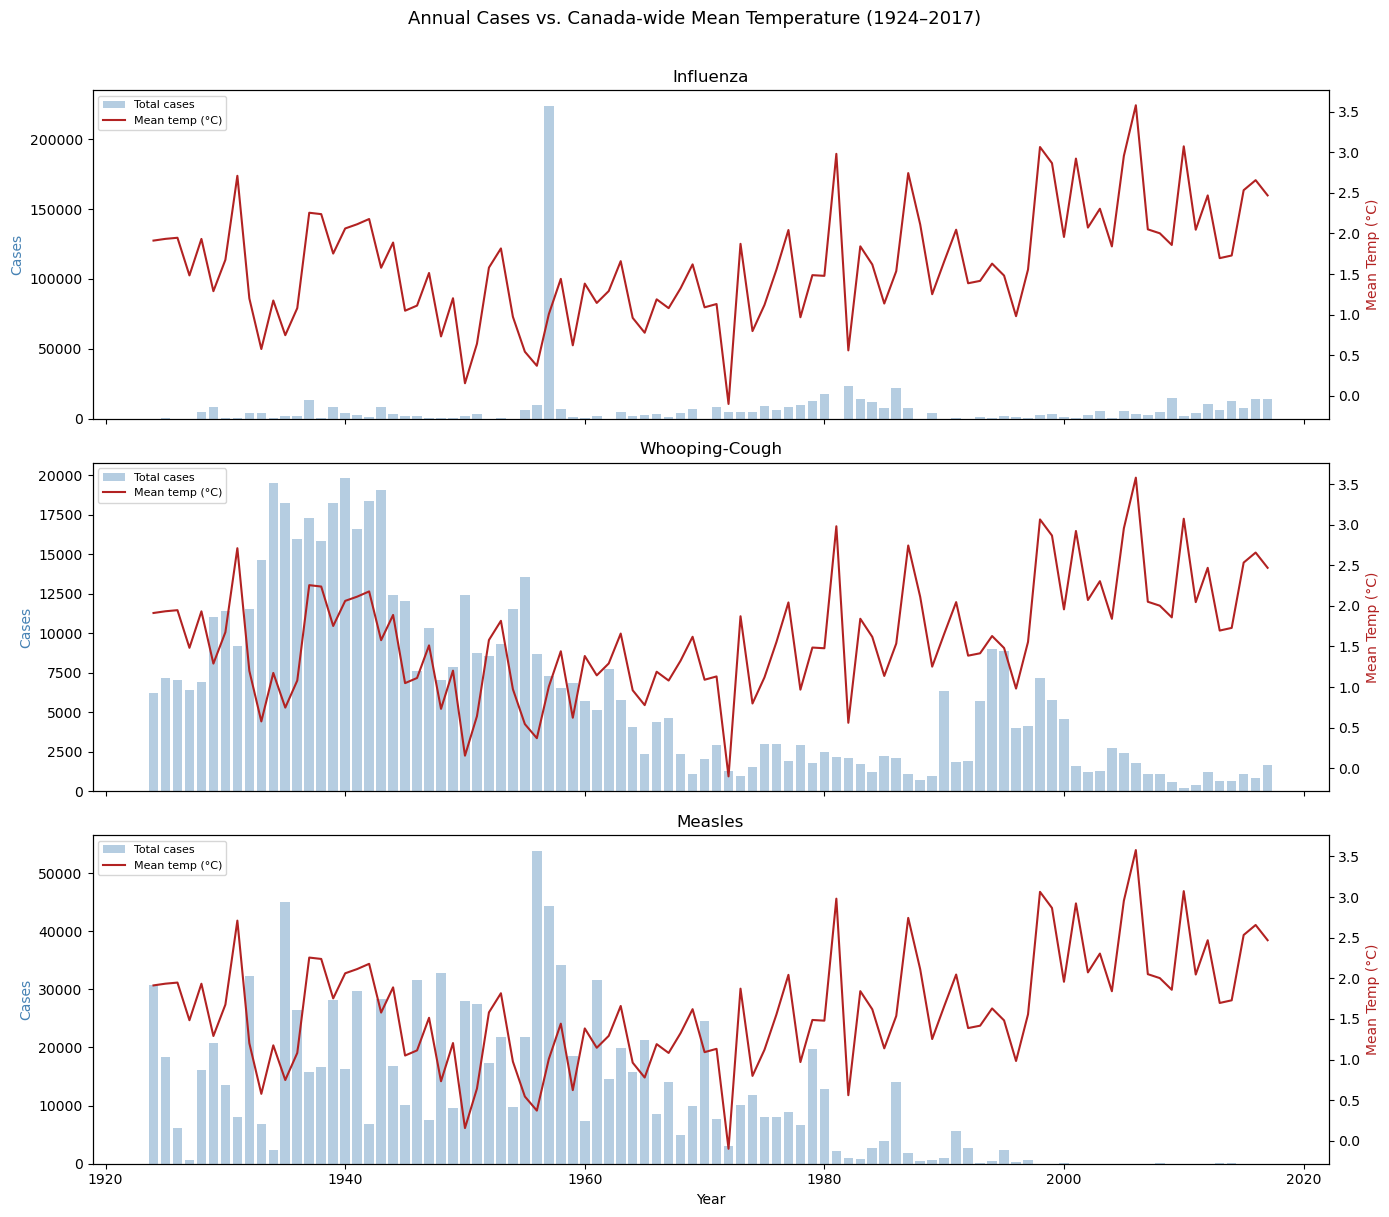

In [9]:
# ── 6a. Canada-wide annual time series: mean temperature + total cases ────
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

annual_temp = (
    climate.groupby('year')['temp_mean']
    .mean()
    .reset_index()
)

for ax, disease_name in zip(axes, FOCUS_DISEASES):
    annual_cases = (
        merged[merged['disease'] == disease_name]
        .groupby('year')['cases_this_period']
        .sum()
        .reset_index()
    )
    ax2 = ax.twinx()
    ax.bar(annual_cases['year'], annual_cases['cases_this_period'],
           alpha=0.4, color='steelblue', label='Total cases')
    ax2.plot(annual_temp['year'], annual_temp['temp_mean'],
             color='firebrick', linewidth=1.5, label='Mean temp (°C)')
    ax.set_ylabel('Cases', color='steelblue')
    ax2.set_ylabel('Mean Temp (°C)', color='firebrick')
    ax.set_title(disease_name.title())
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

axes[-1].set_xlabel('Year')
fig.suptitle('Annual Cases vs. Canada-wide Mean Temperature (1924–2017)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

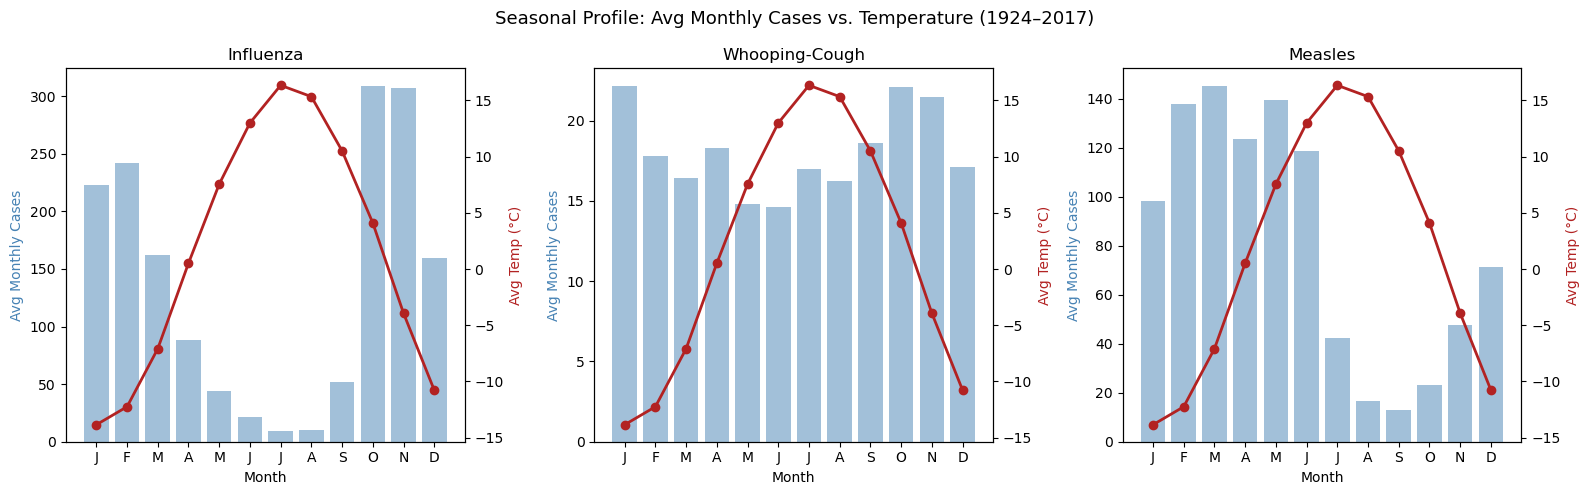

In [10]:
# ── 6b. Seasonal profile: average cases and temperature by month ───────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

monthly_temp = climate.groupby('month')['temp_mean'].mean()

for ax, disease_name in zip(axes, FOCUS_DISEASES):
    monthly_cases = (
        merged[merged['disease'] == disease_name]
        .groupby('month')['cases_this_period']
        .mean()
    )
    ax2 = ax.twinx()
    ax.bar(monthly_cases.index, monthly_cases.values,
           alpha=0.5, color='steelblue', label='Avg cases')
    ax2.plot(monthly_temp.index, monthly_temp.values,
             color='firebrick', marker='o', linewidth=2, label='Avg temp (°C)')
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Monthly Cases', color='steelblue')
    ax2.set_ylabel('Avg Temp (°C)', color='firebrick')
    ax.set_title(disease_name.title())
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

fig.suptitle('Seasonal Profile: Avg Monthly Cases vs. Temperature (1924–2017)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 7. EDA — Precipitation vs. Disease

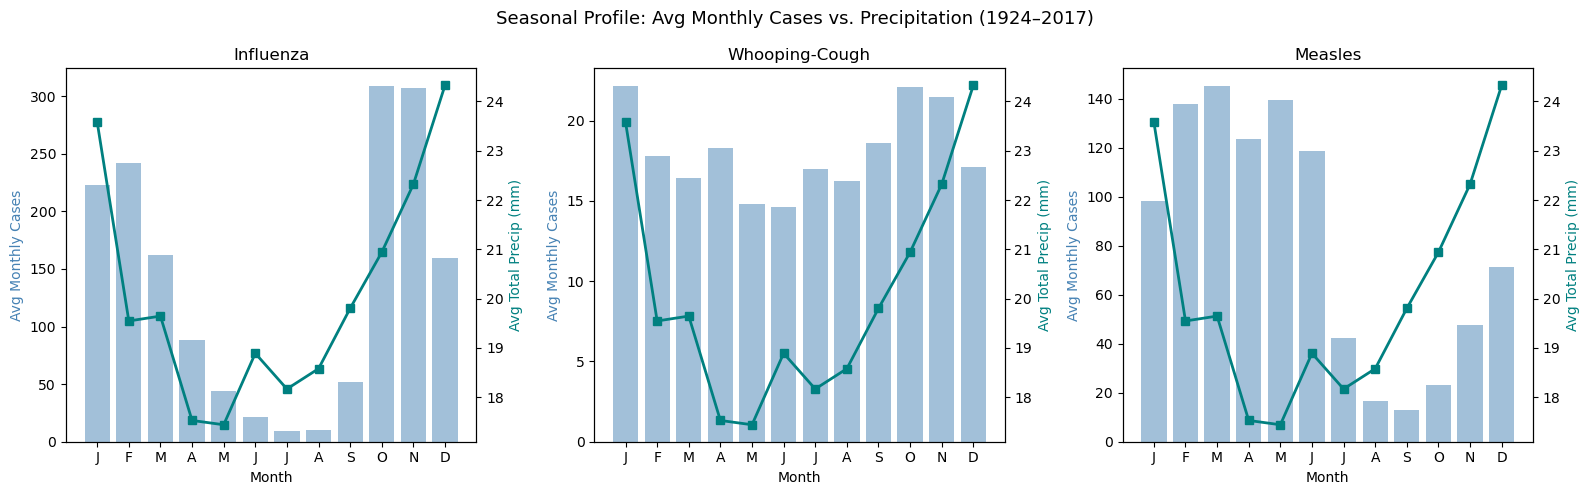

In [11]:
# ── 7a. Seasonal profile: cases vs. total precipitation ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

monthly_precip = climate.groupby('month')['precip_total_mm'].mean()

for ax, disease_name in zip(axes, FOCUS_DISEASES):
    monthly_cases = (
        merged[merged['disease'] == disease_name]
        .groupby('month')['cases_this_period']
        .mean()
    )
    ax2 = ax.twinx()
    ax.bar(monthly_cases.index, monthly_cases.values,
           alpha=0.5, color='steelblue', label='Avg cases')
    ax2.plot(monthly_precip.index, monthly_precip.values,
             color='teal', marker='s', linewidth=2, label='Avg precip (mm)')
    ax.set_xlabel('Month')
    ax.set_ylabel('Avg Monthly Cases', color='steelblue')
    ax2.set_ylabel('Avg Total Precip (mm)', color='teal')
    ax.set_title(disease_name.title())
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

fig.suptitle('Seasonal Profile: Avg Monthly Cases vs. Precipitation (1924–2017)',
             fontsize=13)
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

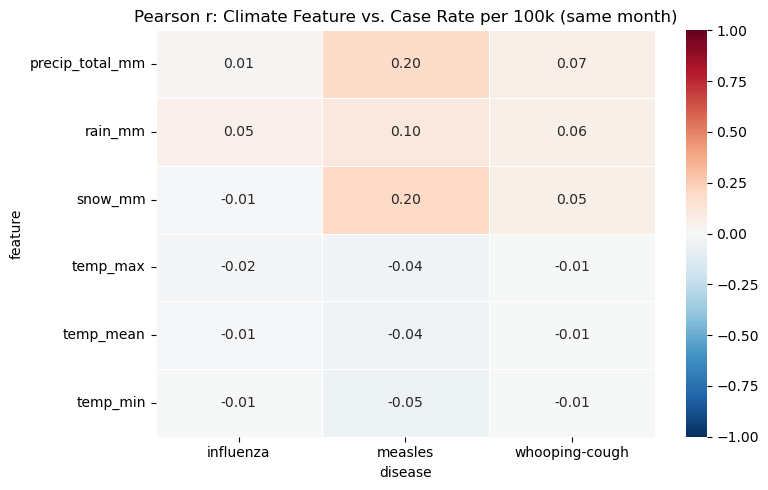

disease          influenza  measles  whooping-cough
feature                                            
precip_total_mm      0.014    0.195           0.070
rain_mm              0.047    0.103           0.061
snow_mm             -0.014    0.201           0.055
temp_max            -0.018   -0.035          -0.008
temp_mean           -0.013   -0.042          -0.006
temp_min            -0.006   -0.052          -0.006


In [12]:
# ── 8a. Pearson correlation: climate features vs. case rate ───────────────
corr_rows = []
for disease_name in FOCUS_DISEASES:
    sub = merged[merged['disease'] == disease_name][climate_cols + ['rate_per_100k']].dropna()
    for col in climate_cols:
        r = sub[[col, 'rate_per_100k']].corr().iloc[0, 1]
        corr_rows.append({'disease': disease_name, 'feature': col, 'pearson_r': r})

corr_df = pd.DataFrame(corr_rows)
corr_pivot = corr_df.pivot(index='feature', columns='disease', values='pearson_r')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(corr_pivot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Pearson r: Climate Feature vs. Case Rate per 100k (same month)')
plt.tight_layout()
plt.show()

print(corr_pivot.round(3))

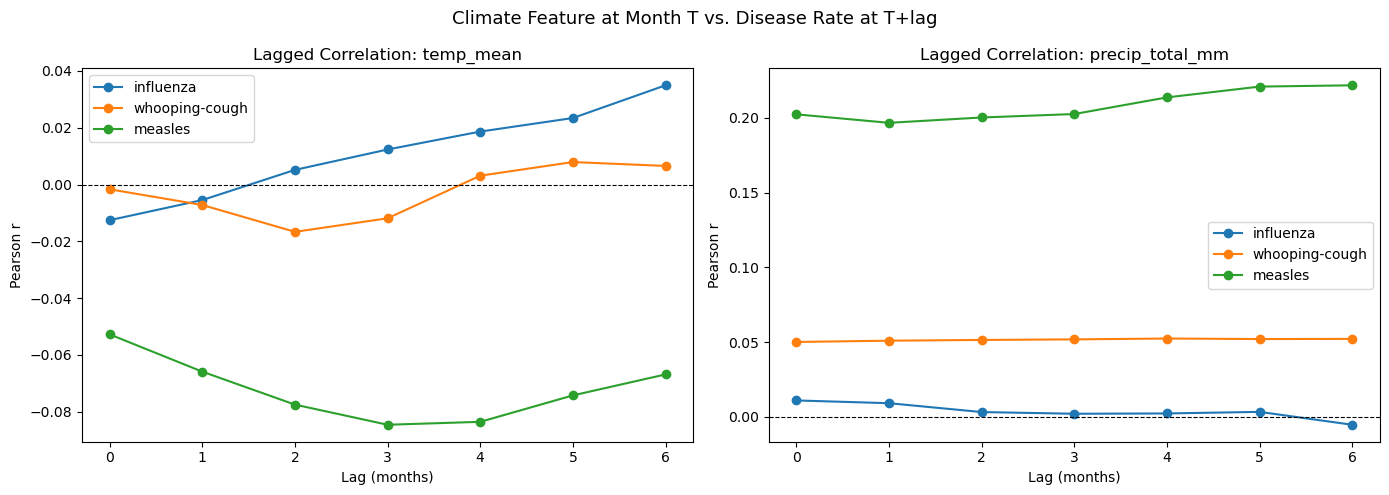

In [13]:
# ── 8b. Lagged correlation: climate at month T vs. cases at T+k ───────────
# Compute lagged correlations for temp_mean and precip_total_mm

LAG_FEATURES = ['temp_mean', 'precip_total_mm']
MAX_LAG = 6

lag_rows = []
for disease_name in FOCUS_DISEASES:
    sub = (
        merged[merged['disease'] == disease_name]
        [['iso', 'year', 'month', 'rate_per_100k'] + LAG_FEATURES]
        .sort_values(['iso', 'year', 'month'])
        .set_index(['iso', 'year', 'month'])
    )
    for feat in LAG_FEATURES:
        for lag in range(0, MAX_LAG + 1):
            lagged = sub[[feat, 'rate_per_100k']].copy()
            lagged[feat] = lagged.groupby(level='iso')[feat].shift(lag)
            r = lagged.dropna()[[feat, 'rate_per_100k']].corr().iloc[0, 1]
            lag_rows.append({'disease': disease_name, 'feature': feat,
                             'lag_months': lag, 'pearson_r': r})

lag_df = pd.DataFrame(lag_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, LAG_FEATURES):
    for disease_name in FOCUS_DISEASES:
        sub = lag_df[(lag_df['feature'] == feat) & (lag_df['disease'] == disease_name)]
        ax.plot(sub['lag_months'], sub['pearson_r'],
                marker='o', label=disease_name)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Pearson r')
    ax.set_title(f'Lagged Correlation: {feat}')
    ax.legend()
    ax.set_xticks(range(0, MAX_LAG + 1))

fig.suptitle('Climate Feature at Month T vs. Disease Rate at T+lag', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Province-level Deep Dive

In [ ]:
# ── 9a. Per-province correlation heatmap ──────────────────────────────────
provinces = sorted(merged['iso'].unique())
feat = 'temp_mean'

prov_corr = {}
for prov in provinces:
    for disease_name in FOCUS_DISEASES:
        sub = merged[(merged['iso'] == prov) & (merged['disease'] == disease_name)]
        sub = sub[[feat, 'rate_per_100k']].dropna()
        if len(sub) >= 12:
            r = sub.corr().iloc[0, 1]
        else:
            r = np.nan
        prov_corr[(prov, disease_name)] = r

prov_corr_df = pd.Series(prov_corr).unstack()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(prov_corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(f'Pearson r: {feat} vs. Case Rate per 100k — by Province')
ax.set_xlabel('Disease')
ax.set_ylabel('Province')
plt.tight_layout()
plt.show()

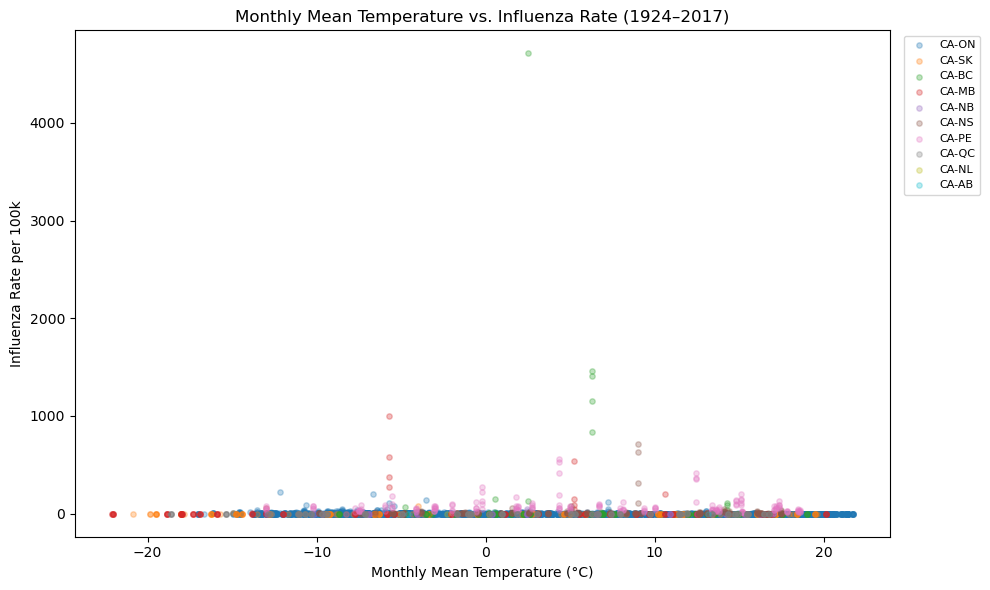

In [15]:
# ── 9b. Scatter: temp_mean vs. influenza rate, coloured by province ────────
inf_data = merged[
    (merged['disease'] == 'influenza') &
    merged['temp_mean'].notna() &
    merged['rate_per_100k'].notna()
].copy()

fig, ax = plt.subplots(figsize=(10, 6))
for prov in inf_data['iso'].unique():
    sub = inf_data[inf_data['iso'] == prov]
    ax.scatter(sub['temp_mean'], sub['rate_per_100k'],
               alpha=0.3, s=15, label=prov)

ax.set_xlabel('Monthly Mean Temperature (°C)')
ax.set_ylabel('Influenza Rate per 100k')
ax.set_title('Monthly Mean Temperature vs. Influenza Rate (1924–2017)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 10. Save Merged Dataset

In [16]:
out_path = DATA_DIR / 'processed' / 'climate_disease_merged.csv'
merged.to_csv(out_path, index=False)
print(f'Saved: {out_path}  ({merged.shape[0]:,} rows, {merged.shape[1]} cols)')
print(merged.head())

Saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/data/processed/climate_disease_merged.csv  (50,408 rows, 14 cols)
     iso period_start_date    disease  cases_this_period  population  year  month  rate_per_100k   temp_max  \
0  CA-ON        1924-01-01  influenza               20.0     3060705  1924      1       0.653444  -5.657439   
1  CA-ON        1924-01-01    measles             1222.0     3060705  1924      1      39.925442  -5.657439   
2  CA-QC        1924-01-01    measles             1517.0     2496770  1924      1      60.758500  -8.693349   
3  CA-SK        1924-01-01  influenza                5.0      791492  1924      1       0.631718 -11.699731   
4  CA-SK        1924-01-01    measles              181.0      791492  1924      1      22.868203 -11.699731   

   temp_mean   temp_min    rain_mm    snow_mm  precip_total_mm  
0 -11.771217 -17.098686  21.693000  33.084286        49.700968  
1 -11.771217 -17.098686  21.693000  33.084286        49.700968  
2 -15.3773

## 11. Summary & Next Steps

### Key observations

- **Temperature**: All temperature features show weak negative same-month correlations (|r| ≤ 0.052 across all three diseases). The direction is consistent — warmer months associate with slightly fewer cases — which is intuitive for respiratory diseases, but the magnitude is too small to claim a meaningful linear relationship at provincial monthly resolution. The lagged analysis shows `temp_mean` for measles strengthens slightly through lag 3 (r = −0.085) before fading. For influenza and whooping-cough, correlations remain essentially flat near zero across all lags.

- **Precipitation**: Largely uncorrelated with all three diseases across all lags (|r| ≤ 0.039 in the lagged analysis). The same-month correlation matrix shows a modest positive signal for measles (`precip_total_mm` r = 0.195, `snow_mm` r = 0.201), but this likely reflects a seasonal confound — both snowfall and measles peak in winter months — rather than a direct causal relationship.

- **Seasonality**: The seasonal profile plots confirm that influenza and whooping-cough peak in winter months (Nov–Mar), aligned with lower temperatures, but the province-level monthly average temperature is too coarse a signal to separate seasonal disease dynamics from other drivers.

- **Lags**: No lag improves the correlation substantially for any disease. The slight strengthening of `temp_mean` vs. measles at lag 3 is the most notable lag signal, but remains weak (r = −0.085).

- **Province variation**: Province-level heatmap shows heterogeneous results. Correlations vary in direction and magnitude across provinces, suggesting no consistent national-level climate–disease relationship.

### Overall assessment

No climate feature produces a correlation above |r| = 0.21. Climate signals seem largely washed out at a province level in this dataset. It is far more likely that things like population density and vaccination program rollouts dominate over climate at this scale.

### Possible feature engineering to incorporate if we move in this direction
- `temp_mean` (monthly province-level mean temperature, continuous)
- Temperature anomaly (deviation from the long-run monthly climatological average per province — removes the seasonal confound and isolates year-to-year variation)
- Cold-month indicator (`temp_mean < 0°C`) — captures winter seasonality directly
- Lagged `temp_mean` at T−3 (marginal signal for measles)
- `precip_total_mm` if model scope stays within 1924–2017; otherwise drop

### Decision On Go Ahead

We need to make a decision and align on if we want to incorporate climate data at a limited scale or if we want to set it aside.